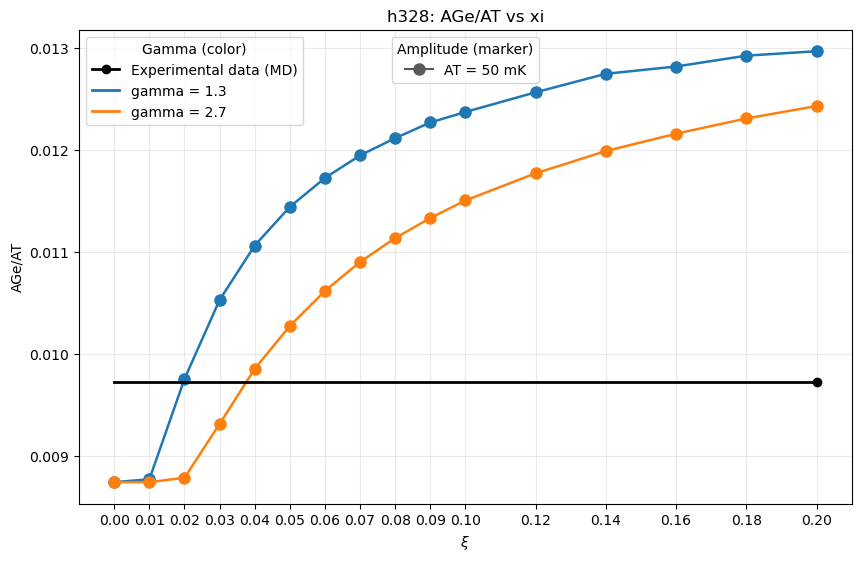

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h328_AGe_AT_vs_xi_auto_MD.png
Plotted 32 h328 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Amplitude (marker): [50.0]
Experimental set: MD


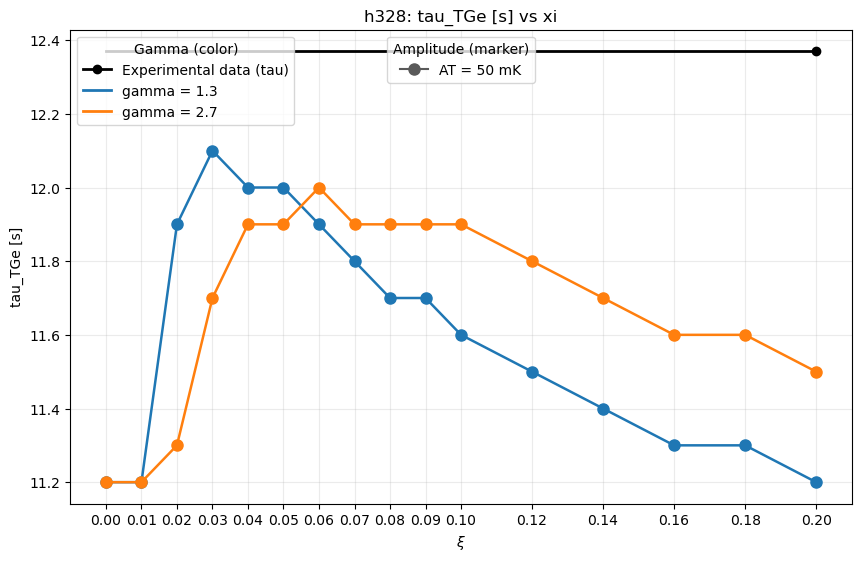

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h328_tau_TGe_s_vs_xi_auto_tau.png
Plotted 32 h328 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Amplitude (marker): [50.0]
Experimental set: tau


In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

experiment = {
'MD' : {
    'h328' : [0.009728699],
    'h429' : [0.008389866, 0.009830653, 0.010428079],
    'h430' : [0.008618964, 0.009882085, 0.010841218],
    'h431' : [0.011079281, 0.006836176, 0.003885869],
    'h432' : [0.005892374, 0.006650729, 0.006959009],
    'h433' : [0.009359831, 0.009789618, 0.01143509]
    },
'tau' : {
    'h328' : [12.37],
    'h429' : [29.79, 25.00, 27.81],
    'h430' : [22.10, 27.79, 30.72],
    'h431' : [40.02, 11.84, 4.54],
    'h432' : [12.55, 12.56, 13.98],
    'h433' : [29.96, 29.73, 30.95]
    }
}


def plot(file, y_column="AGe/AT", experiment_type="MD"):
    """Plot AGe/AT or a tau column against xi using only auto result files."""
    column_experiment = {
        "AGe/AT": "MD",
        "tau_TB [s]": "tau",
        "tau_TGe [s]": "tau",
    }
    if y_column not in column_experiment:
        raise ValueError(f"Unsupported y_column {y_column!r}; choose from {sorted(column_experiment)}.")
    if experiment_type != column_experiment[y_column]:
        raise ValueError(f"{y_column!r} requires experiment_type={column_experiment[y_column]!r}.")
    if file not in experiment[experiment_type]:
        raise ValueError(f"No {experiment_type} experimental data configured for {file!r}.")

    cwd = Path.cwd()
    candidates = [cwd, cwd / "results", cwd / "data_output" / "results"]
    results_dir = next(
        (path for path in candidates if list(path.glob("gamma_*_xi_*_output.csv"))),
        None,
    )
    if results_dir is None:
        raise FileNotFoundError("Could not find gamma_*_xi_*_output.csv in the current directory or results subfolder.")

    filename_pattern = re.compile(r"gamma_([^_]+)_xi_([^_]+)(?:_(.+))?_output\.csv$")
    frames = []
    for path in sorted(results_dir.glob("gamma_*_xi_*_output.csv")):
        match = filename_pattern.search(path.name)
        if match is None or match.group(3) != "auto":
            continue

        gamma = float(match.group(1).replace("p", ".").replace("d", "."))
        xi = float(match.group(2).replace("p", ".").replace("d", "."))
        data = pd.read_csv(path, sep="\t")
        data.columns = data.columns.str.strip()
        data["Source_File"] = data["Source_File"].astype(str).str.strip()
        data = data.loc[data["Source_File"] == f"{file}_output"].copy()
        data["Plot_Value"] = pd.to_numeric(data[y_column], errors="coerce")

        if file == "h431":
            data["Marker_Value"] = pd.to_numeric(data["f [Hz]"], errors="coerce")
        else:
            data["Marker_Value"] = pd.to_numeric(data["sweep through AT"], errors="coerce")

        data = data.dropna(subset=["Plot_Value", "Marker_Value"])
        data["gamma"] = gamma
        data["xi"] = xi
        frames.append(data[["gamma", "xi", "Marker_Value", "Plot_Value"]])

    if not frames:
        raise ValueError(f"No {file}_output rows found for y_column={y_column!r} in auto result files.")

    plot_data = pd.concat(frames, ignore_index=True)
    gammas = sorted(plot_data["gamma"].unique())
    marker_values = sorted(plot_data["Marker_Value"].unique())
    colors = dict(zip(gammas, plt.get_cmap("tab10").colors[:len(gammas)]))
    marker_shapes = ["o", "s", "^"]
    markers = {
        marker_value: marker_shapes[index % len(marker_shapes)]
        for index, marker_value in enumerate(marker_values)
    }

    fig, ax = plt.subplots(figsize=(8.5, 5.5), constrained_layout=True)
    for (gamma, marker_value), group in plot_data.groupby(["gamma", "Marker_Value"], sort=True):
        group = group.sort_values("xi")
        ax.plot(
            group["xi"],
            group["Plot_Value"],
            color=colors[gamma],
            marker=markers[marker_value],
            markersize=8,
            linewidth=1.8,
        )

    ax.set_xlabel(r"$\xi$")
    ax.set_ylabel(y_column)
    ax.set_title(f"{file}: {y_column} vs xi")
    ax.set_xticks(sorted(plot_data["xi"].unique()))
    ax.grid(True, alpha=0.25)

    if file == "h431":
        marker_title = "Frequency (marker)"
        marker_labels = [f"f = {value:g} Hz" for value in marker_values]
        experimental_marker_values = [0.03, 0.01, 0.0033]
    else:
        marker_title = "Amplitude (marker)"
        marker_labels = [f"AT = {value:g} mK" for value in marker_values]
        experimental_marker_values = marker_values

    experimental_values = experiment[experiment_type][file]
    for index, (marker_value, value) in enumerate(zip(experimental_marker_values, experimental_values)):
        ax.plot(
            [0, 0.2],
            [value, value],
            color="black",
            linewidth=2,
            marker=markers.get(marker_value, "D"),
            markevery=[1],
            label=f"Experimental data ({experiment_type})" if index == 0 else "_nolegend_",
        )

    color_legend = [
        Line2D([0], [0], color=colors[gamma], linewidth=2, label=f"gamma = {gamma:g}")
        for gamma in gammas
    ]
    handles, _ = ax.get_legend_handles_labels()
    all_handles = handles + color_legend
    marker_legend = [
        Line2D(
            [0], [0], color="0.35", marker=markers[value],
            linestyle="-", markersize=8, label=label
        )
        for value, label in zip(marker_values, marker_labels)
    ]
    gamma_legend = ax.legend(handles=all_handles, title="Gamma (color)", loc="upper left")
    ax.add_artist(gamma_legend)
    ax.legend(handles=marker_legend, title=marker_title, loc="upper center")

    safe_column = re.sub(r"[^A-Za-z0-9_-]+", "_", y_column).strip("_")
    output_path = results_dir / f"{file}_{safe_column}_vs_xi_auto_{experiment_type}.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to: {output_path}")
    print(f"Plotted {len(plot_data)} {file} rows from {len(frames)} auto files.")
    print(f"xi values: {sorted(plot_data['xi'].unique())}; {marker_title}: {marker_values}")
    print(f"Experimental set: {experiment_type}")

plot('h328')
plot('h328', y_column='tau_TGe [s]', experiment_type='tau')

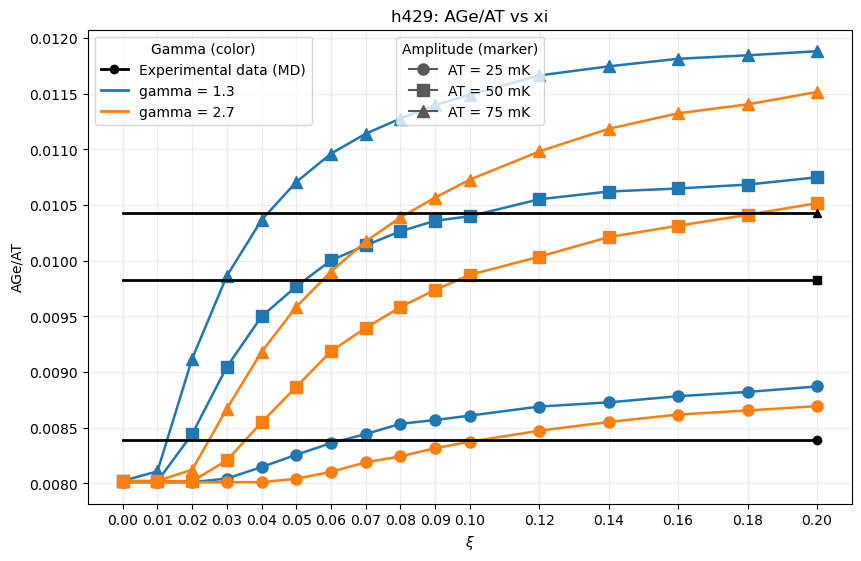

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h429_AGe_AT_vs_xi_auto_MD.png
Plotted 96 h429 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Amplitude (marker): [25.0, 50.0, 75.0]
Experimental set: MD


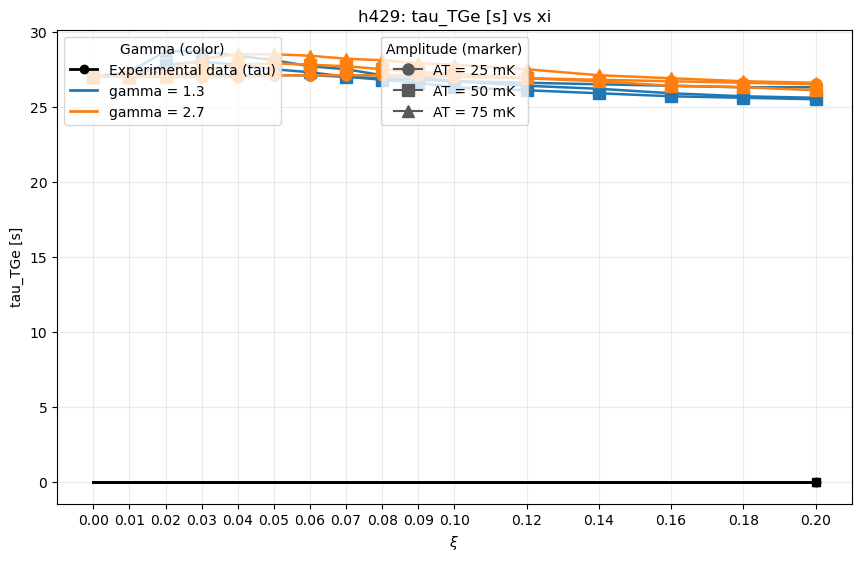

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h429_tau_TGe_s_vs_xi_auto_tau.png
Plotted 96 h429 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Amplitude (marker): [25.0, 50.0, 75.0]
Experimental set: tau


In [28]:
plot('h429')
plot('h429', y_column='tau_TGe [s]', experiment_type='tau')

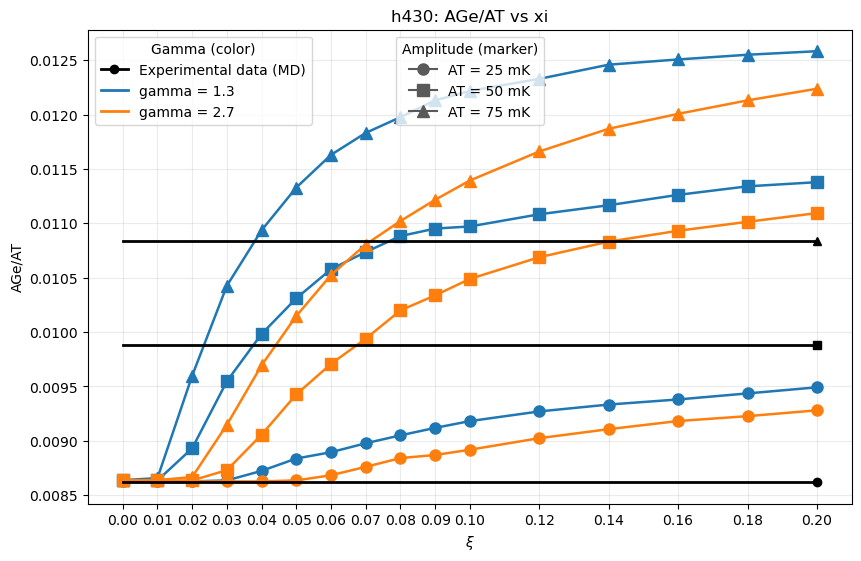

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h430_AGe_AT_vs_xi_auto_MD.png
Plotted 96 h430 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Amplitude (marker): [25.0, 50.0, 75.0]
Experimental set: MD


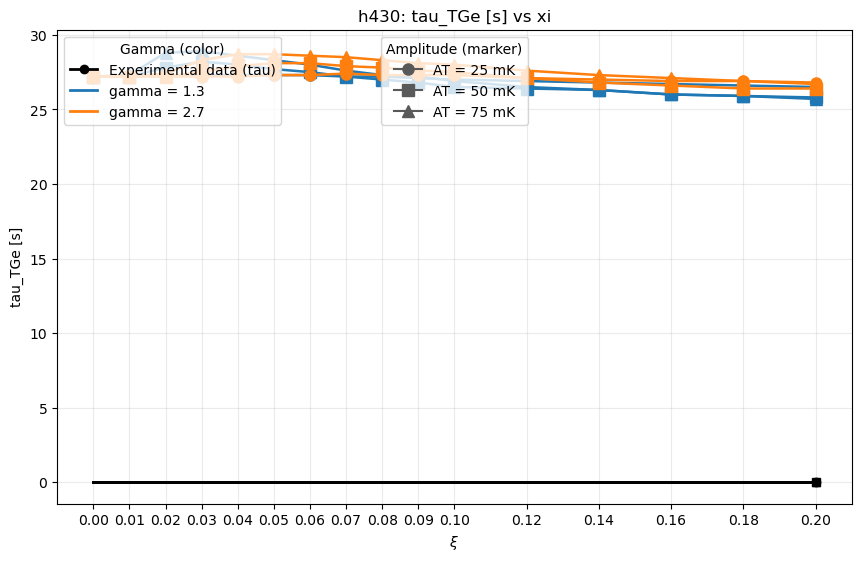

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h430_tau_TGe_s_vs_xi_auto_tau.png
Plotted 96 h430 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Amplitude (marker): [25.0, 50.0, 75.0]
Experimental set: tau


In [29]:
plot('h430')
plot('h430', y_column='tau_TGe [s]', experiment_type='tau')

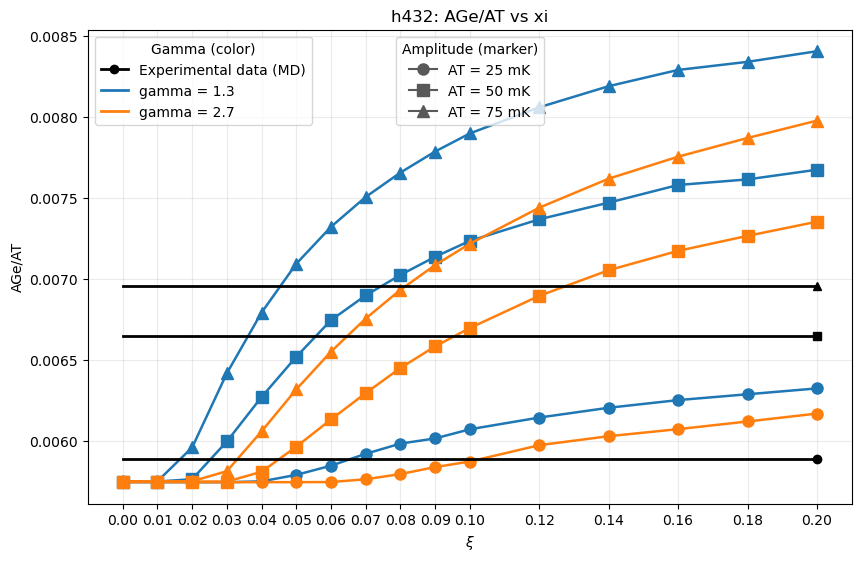

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h432_AGe_AT_vs_xi_auto_MD.png
Plotted 96 h432 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Amplitude (marker): [25.0, 50.0, 75.0]
Experimental set: MD


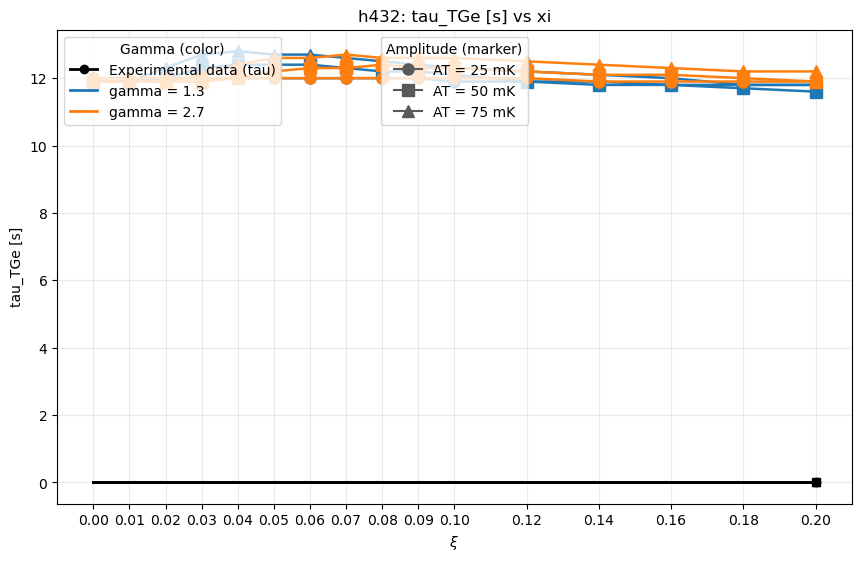

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h432_tau_TGe_s_vs_xi_auto_tau.png
Plotted 96 h432 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Amplitude (marker): [25.0, 50.0, 75.0]
Experimental set: tau


In [30]:
plot('h432')
plot('h432', y_column='tau_TGe [s]', experiment_type='tau')

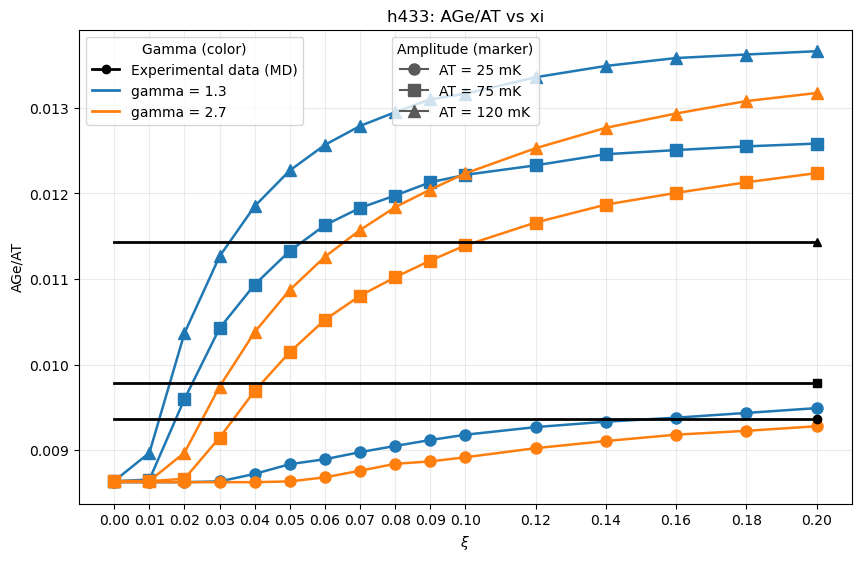

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h433_AGe_AT_vs_xi_auto_MD.png
Plotted 96 h433 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Amplitude (marker): [25.0, 75.0, 120.0]
Experimental set: MD


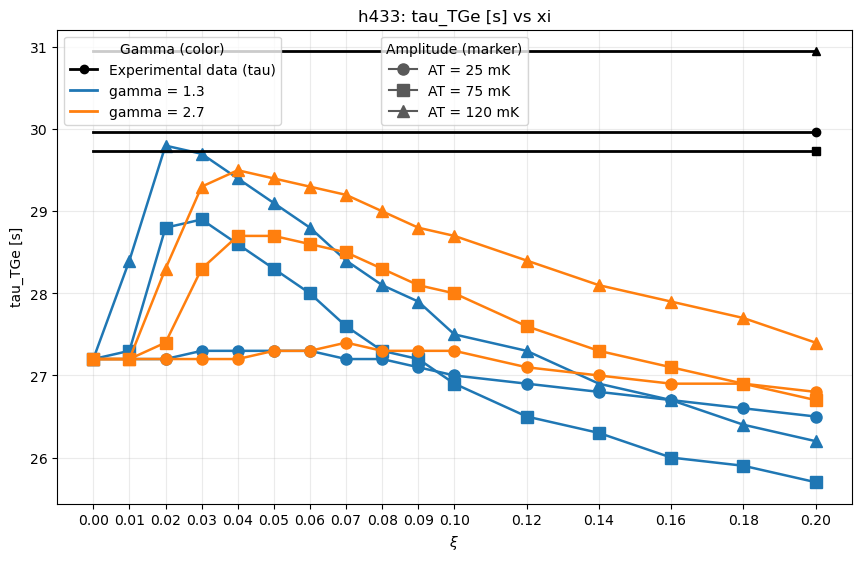

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h433_tau_TGe_s_vs_xi_auto_tau.png
Plotted 96 h433 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Amplitude (marker): [25.0, 75.0, 120.0]
Experimental set: tau


In [31]:
plot('h433')
plot('h433', y_column='tau_TGe [s]', experiment_type='tau')

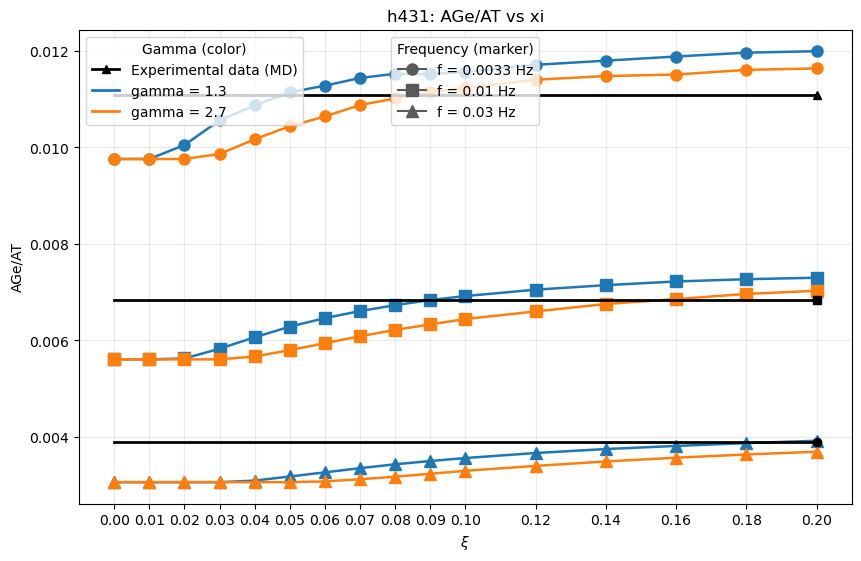

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h431_AGe_AT_vs_xi_auto_MD.png
Plotted 96 h431 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Frequency (marker): [0.0033, 0.01, 0.03]
Experimental set: MD


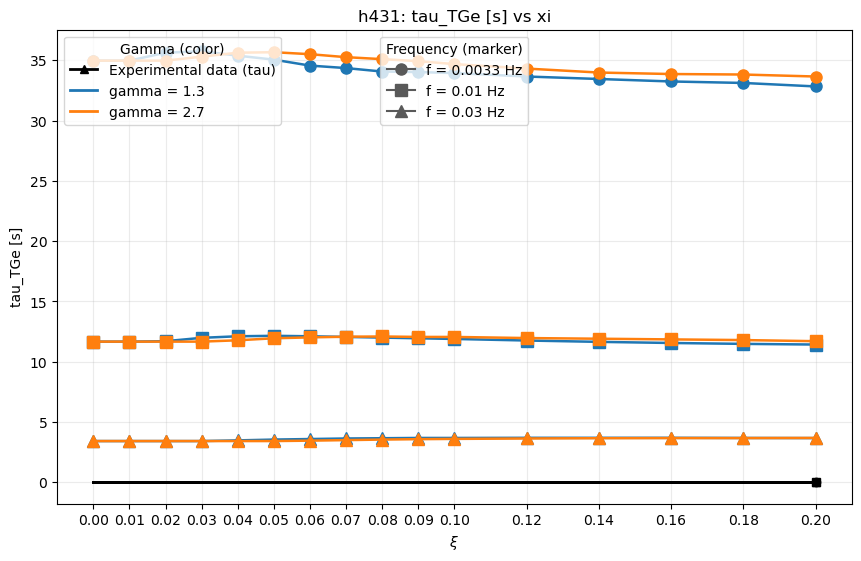

Saved plot to: c:\Users\sulta\Documents\UPT  - kryogenika\starsi_veci_bakalar\thermodynamic_model\data_output\results\h431_tau_TGe_s_vs_xi_auto_tau.png
Plotted 96 h431 rows from 32 auto files.
xi values: [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2]; Frequency (marker): [0.0033, 0.01, 0.03]
Experimental set: tau


In [32]:
plot('h431')
plot('h431', y_column='tau_TGe [s]', experiment_type='tau')